<a href="https://colab.research.google.com/github/mdakram0778/Case-Study-Stock-Price-Analysis-of-IT-Companies/blob/main/Car_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## How to Upload Files in Colab

There are a few ways to upload files to your Colab environment:

1.  **Using the Files tab (recommended for small files):**
    *   On the left sidebar, click the "Files" icon (folder icon).
    *   Click the "Upload" icon (up arrow) and select your file from your local computer.
    *   The file will be temporarily stored in the Colab environment (usually in `/content/`).

2.  **Using `files.upload()` (for programmatic upload):**
    *   Run the Python code below. It will prompt you to choose files from your local system.

3.  **Mounting Google Drive:**
    *   If your files are in Google Drive, you can mount your Drive to Colab. This is great for larger datasets or persistent storage.
    *   Run the code: `from google.colab import drive; drive.mount('/content/drive')`
    *   After authentication, your Drive will be accessible at `/content/drive/My Drive/`.

Once your file is uploaded, you can access it by its path. For example, if you uploaded a `data.csv` file, you can read it with pandas like this:

In [2]:
import pandas as pd
from google.colab import files

# Option 1: Use files.upload() for programmatic upload
# uploaded = files.upload()
# for filename in uploaded.keys():
#   print(f'Uploaded file "{filename}" with length {len(uploaded[filename])} bytes')

# Assuming you have uploaded a file named 'data.csv' via the Files tab or programmatically
try:
    df = pd.read_csv('data.csv')
    print("File 'data.csv' loaded successfully.")
    display(df.head())
except FileNotFoundError:
    print("Error: 'data.csv' not found. Please upload the file first.")
except Exception as e:
    print(f"An error occurred: {e}")

Error: 'data.csv' not found. Please upload the file first.


In [4]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
  print(f'Uploaded file "{filename}" with length {len(uploaded[filename])} bytes')

# Now you can try to read your uploaded file, for example, if it's named 'data.csv'
# df = pd.read_csv('data.csv')
# display(df.head())

Saving car_prices.csv to car_prices (1).csv
Uploaded file "car_prices (1).csv" with length 88047552 bytes


In [7]:
import pandas as pd

# The file was saved as 'car_prices (1).csv'
file_name = 'car_prices (1).csv'

try:
    df_car_prices = pd.read_csv(file_name)
    print(f"File '{file_name}' loaded successfully into a DataFrame.")
    print("Here are the first 5 rows of your data:")
    display(df_car_prices.head())
except FileNotFoundError:
    print(f"Error: '{file_name}' not found. Please ensure the file is uploaded.")
except Exception as e:
    print(f"An error occurred while reading the file: {e}")

File 'car_prices (1).csv' loaded successfully into a DataFrame.
Here are the first 5 rows of your data:


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [5]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Dataset Information
df_car_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


### Checking for Missing Values

Let's quantify the missing values in each column to understand their extent.

In [11]:
df_car_prices.shape

(558837, 16)

In [15]:
# Display column names
df_car_prices.columns

Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state',
       'condition', 'odometer', 'color', 'interior', 'seller', 'mmr',
       'sellingprice', 'saledate'],
      dtype='object')

In [16]:
# Display column names
df_car_prices.columns

Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state',
       'condition', 'odometer', 'color', 'interior', 'seller', 'mmr',
       'sellingprice', 'saledate'],
      dtype='object')

In [17]:
# Display data types
df_car_prices.dtypes

,0
year,int64
make,object
model,object
trim,object
body,object
transmission,object
vin,object
state,object
condition,float64
odometer,float64


In [18]:
# Count missing values
df_car_prices.isnull().sum()

,0
year,0
make,10301
model,10399
trim,10651
body,13195
transmission,0
vin,4
state,0
condition,11820
odometer,94


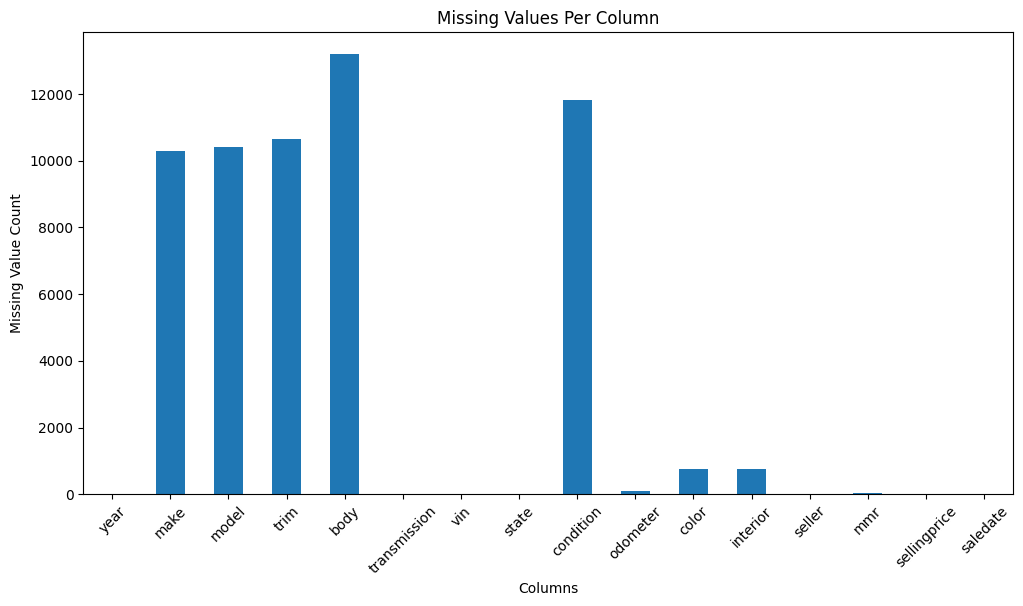

In [19]:
# Visualize missing values using bar chart

plt.figure(figsize=(12,6))

df_car_prices.isnull().sum().plot(kind='bar')

plt.title('Missing Values Per Column')

plt.xlabel('Columns')
plt.ylabel('Missing Value Count')

plt.xticks(rotation=45)

plt.show()

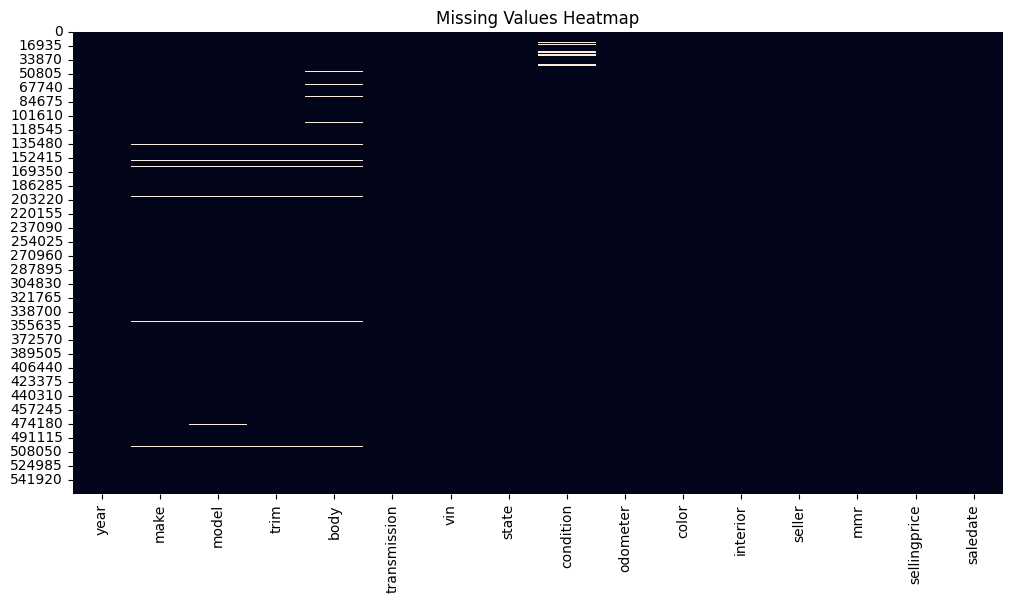

In [20]:
# Heatmap for missing values

plt.figure(figsize=(12,6))

sns.heatmap(df_car_prices.isnull(), cbar=False)

plt.title('Missing Values Heatmap')

plt.show()

In [21]:
# Count duplicate records
df_car_prices.duplicated().sum()


np.int64(0)

In [22]:
# Remove duplicate records
df_car_prices.drop_duplicates(inplace=True)

In [23]:
# Verify duplicates removed
df_car_prices.duplicated().sum()

np.int64(0)

In [24]:
# Verify duplicates removed
df_car_prices.duplicated().sum()

np.int64(0)

In [26]:
# Fill numerical missing values with median

num_cols = ['condition', 'odometer', 'mmr', 'sellingprice']

for col in num_cols:
    df_car_prices[col].fillna(df_car_prices[col].median(), inplace=True)

/tmp/ipykernel_3554/3802690925.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_car_prices[col].fillna(df_car_prices[col].median(), inplace=True)


In [27]:
# Fill categorical missing values with mode

cat_cols = ['make', 'model', 'trim', 'body',
            'transmission', 'color',
            'interior', 'seller', 'state']

for col in cat_cols:
    df_car_prices[col].fillna(df_car_prices[col].mode()[0], inplace=True)

/tmp/ipykernel_3554/1512499565.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_car_prices[col].fillna(df_car_prices[col].mode()[0], inplace=True)


In [28]:
# Check missing values again
df_car_prices.isnull().sum()

,0
year,0
make,0
model,0
trim,0
body,0
transmission,0
vin,4
state,0
condition,0
odometer,0


In [29]:
# Save cleaned dataset
df_car_prices.to_csv('cleaned_car_prices.csv', index=False)

In [10]:
# Calculate and display the number of missing values per column
missing_values_count = df_car_prices.isnull().sum()

# Filter to show only columns with missing values
missing_values_count = missing_values_count[missing_values_count > 0]

print("Number of missing values per column:")
print(missing_values_count.sort_values(ascending=False))

Number of missing values per column:
transmission    65352
body            13195
condition       11820
trim            10651
model           10399
make            10301
color             749
interior          749
odometer           94
mmr                38
sellingprice       12
saledate           12
vin                 4
dtype: int64


In [30]:
# Average, Minimum and Maximum Selling Price

print("Average Price:", df_car_prices['sellingprice'].mean())

print("Minimum Price:", df_car_prices['sellingprice'].min())

print("Maximum Price:", df_car_prices['sellingprice'].max())

Average Price: 13611.326356343621
Minimum Price: 1.0
Maximum Price: 230000.0


In [31]:
# Average car selling price
df_car_prices['sellingprice'].mean()

np.float64(13611.326356343621)

In [32]:
# Average car selling price
df_car_prices['sellingprice'].mean()

np.float64(13611.326356343621)

In [33]:
# Minimum car selling price
df_car_prices['sellingprice'].min()

1.0

In [34]:
# Maximum car selling price
df_car_prices['sellingprice'].max()

230000.0

In [38]:
# Unique car models

df_car_prices['model'].nunique()

973

In [39]:
# Unique car brands

df_car_prices['make'].nunique()

96

In [40]:
# Cars with selling price greater than 165000

high_price_cars = df_car_prices[df_car_prices['sellingprice'] > 165000]

high_price_cars

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
125095,2012,Rolls-Royce,Ghost,Base,Sedan,automatic,sca664s58cux50727,fl,45.0,14316.0,black,beige,braman motorcars,154000.0,169500.0,Wed Jan 14 2015 01:40:00 GMT-0800 (PST)
344905,2014,Ford,Escape,Titanium,SUV,automatic,1fmcu9j98eua23833,mo,43.0,27802.0,green,tan,ford-lincoln dealer program,22800.0,230000.0,Wed Feb 25 2015 02:00:00 GMT-0800 (PST)
446949,2015,Mercedes-Benz,S-Class,S65 AMG,Sedan,automatic,wddug7kb2fa102347,ca,41.0,5277.0,white,white,mercedes-benz usa,170000.0,173000.0,Thu May 21 2015 05:00:00 GMT-0700 (PDT)
538347,2012,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s59cux50803,ca,44.0,5215.0,white,tan,financial services remarketing (bmw int),166000.0,167000.0,Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)
545523,2013,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s52dux52152,fl,42.0,7852.0,white,beige,flag/landrover southpointe,178000.0,171500.0,Wed Jun 17 2015 03:05:00 GMT-0700 (PDT)
548169,2011,Ferrari,458 Italia,Base,coupe,automatic,zff67nfa1b0178698,fl,46.0,12116.0,red,black,platinum motor cars,182000.0,183000.0,Wed Jun 17 2015 03:40:00 GMT-0700 (PDT)
557570,2012,Rolls-Royce,Ghost,EWB,sedan,automatic,sca664l50cux65625,ca,36.0,11832.0,white,black,bentley scottsdale,164000.0,169000.0,Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)


In [35]:
# Unique car colors

df_car_prices['color'].unique()

array(['white', 'gray', 'black', 'red', 'silver', 'blue', 'brown',
       'beige', 'purple', 'burgundy', '—', 'gold', 'yellow', 'green',
       'charcoal', 'orange', 'off-white', 'turquoise', 'pink', 'lime',
       '4802', '9410', '1167', '2172', '14872', '12655', '15719', '6388',
       '16633', '11034', '2711', '6864', '339', '18384', '9887', '9837',
       '20379', '20627', '721', '6158', '2817', '5705', '18561', '2846',
       '9562', '5001'], dtype=object)

In [36]:
# Unique car colors

df_car_prices['color'].unique()

array(['white', 'gray', 'black', 'red', 'silver', 'blue', 'brown',
       'beige', 'purple', 'burgundy', '—', 'gold', 'yellow', 'green',
       'charcoal', 'orange', 'off-white', 'turquoise', 'pink', 'lime',
       '4802', '9410', '1167', '2172', '14872', '12655', '15719', '6388',
       '16633', '11034', '2711', '6864', '339', '18384', '9887', '9837',
       '20379', '20627', '721', '6158', '2817', '5705', '18561', '2846',
       '9562', '5001'], dtype=object)

In [37]:
# Number of unique car brands

print("Unique Car Brands:", df_car_prices['make'].nunique())

# Number of unique car models

print("Unique Car Models:", df_car_prices['model'].nunique())

Unique Car Brands: 96
Unique Car Models: 973


### Handling Missing Values in 'transmission' column

The `transmission` column has the highest number of missing values. We'll start by imputing these missing values with the mode (most frequent value) of the column, as it's a categorical feature.

In [14]:
df_car_prices.columns

Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state',
       'condition', 'odometer', 'color', 'interior', 'seller', 'mmr',
       'sellingprice', 'saledate'],
      dtype='object')

In [41]:
# Top 5 most sold car models

df_car_prices['model'].value_counts().head(5)

,count
model,
Altima,29748
F-150,14479
Fusion,12946
Camry,12545
Escape,11861


In [42]:
# Number of unique car brands

print("Unique Car Brands:", df_car_prices['make'].nunique())

# Number of unique car models

print("Unique Car Models:", df_car_prices['model'].nunique())

Unique Car Brands: 96
Unique Car Models: 973


In [43]:
# Unique car colors

df_car_prices['color'].unique()

array(['white', 'gray', 'black', 'red', 'silver', 'blue', 'brown',
       'beige', 'purple', 'burgundy', '—', 'gold', 'yellow', 'green',
       'charcoal', 'orange', 'off-white', 'turquoise', 'pink', 'lime',
       '4802', '9410', '1167', '2172', '14872', '12655', '15719', '6388',
       '16633', '11034', '2711', '6864', '339', '18384', '9887', '9837',
       '20379', '20627', '721', '6158', '2817', '5705', '18561', '2846',
       '9562', '5001'], dtype=object)

In [44]:
# Number of unique car brands

print("Unique Car Brands:", df_car_prices['make'].nunique())

# Number of unique car models

print("Unique Car Models:", df_car_prices['model'].nunique())

Unique Car Brands: 96
Unique Car Models: 973


In [45]:
# Number of unique car brands

print("Unique Car Brands:", df_car_prices['make'].nunique())

# Number of unique car models

print("Unique Car Models:", df_car_prices['model'].nunique())

Unique Car Brands: 96
Unique Car Models: 973


In [46]:
# Cars with selling price greater than 165000

high_price_cars = df_car_prices[df_car_prices['sellingprice'] > 165000]

high_price_cars

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
125095,2012,Rolls-Royce,Ghost,Base,Sedan,automatic,sca664s58cux50727,fl,45.0,14316.0,black,beige,braman motorcars,154000.0,169500.0,Wed Jan 14 2015 01:40:00 GMT-0800 (PST)
344905,2014,Ford,Escape,Titanium,SUV,automatic,1fmcu9j98eua23833,mo,43.0,27802.0,green,tan,ford-lincoln dealer program,22800.0,230000.0,Wed Feb 25 2015 02:00:00 GMT-0800 (PST)
446949,2015,Mercedes-Benz,S-Class,S65 AMG,Sedan,automatic,wddug7kb2fa102347,ca,41.0,5277.0,white,white,mercedes-benz usa,170000.0,173000.0,Thu May 21 2015 05:00:00 GMT-0700 (PDT)
538347,2012,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s59cux50803,ca,44.0,5215.0,white,tan,financial services remarketing (bmw int),166000.0,167000.0,Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)
545523,2013,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s52dux52152,fl,42.0,7852.0,white,beige,flag/landrover southpointe,178000.0,171500.0,Wed Jun 17 2015 03:05:00 GMT-0700 (PDT)
548169,2011,Ferrari,458 Italia,Base,coupe,automatic,zff67nfa1b0178698,fl,46.0,12116.0,red,black,platinum motor cars,182000.0,183000.0,Wed Jun 17 2015 03:40:00 GMT-0700 (PDT)
557570,2012,Rolls-Royce,Ghost,EWB,sedan,automatic,sca664l50cux65625,ca,36.0,11832.0,white,black,bentley scottsdale,164000.0,169000.0,Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)


In [47]:
# Cars with selling price greater than 165000

high_price_cars = df_car_prices[df_car_prices['sellingprice'] > 165000]

high_price_cars

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
125095,2012,Rolls-Royce,Ghost,Base,Sedan,automatic,sca664s58cux50727,fl,45.0,14316.0,black,beige,braman motorcars,154000.0,169500.0,Wed Jan 14 2015 01:40:00 GMT-0800 (PST)
344905,2014,Ford,Escape,Titanium,SUV,automatic,1fmcu9j98eua23833,mo,43.0,27802.0,green,tan,ford-lincoln dealer program,22800.0,230000.0,Wed Feb 25 2015 02:00:00 GMT-0800 (PST)
446949,2015,Mercedes-Benz,S-Class,S65 AMG,Sedan,automatic,wddug7kb2fa102347,ca,41.0,5277.0,white,white,mercedes-benz usa,170000.0,173000.0,Thu May 21 2015 05:00:00 GMT-0700 (PDT)
538347,2012,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s59cux50803,ca,44.0,5215.0,white,tan,financial services remarketing (bmw int),166000.0,167000.0,Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)
545523,2013,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s52dux52152,fl,42.0,7852.0,white,beige,flag/landrover southpointe,178000.0,171500.0,Wed Jun 17 2015 03:05:00 GMT-0700 (PDT)
548169,2011,Ferrari,458 Italia,Base,coupe,automatic,zff67nfa1b0178698,fl,46.0,12116.0,red,black,platinum motor cars,182000.0,183000.0,Wed Jun 17 2015 03:40:00 GMT-0700 (PDT)
557570,2012,Rolls-Royce,Ghost,EWB,sedan,automatic,sca664l50cux65625,ca,36.0,11832.0,white,black,bentley scottsdale,164000.0,169000.0,Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)


In [48]:
# Average selling price by make

avg_price_by_make = df_car_prices.groupby('make')['sellingprice'].mean()

avg_price_by_make.sort_values(ascending=False)

,sellingprice
make,
Rolls-Royce,153488.235294
Ferrari,127210.526316
Lamborghini,112625.000000
Bentley,74367.672414
airstream,71000.000000
...,...
dodge tk,550.000000
Geo,528.947368
dot,500.000000


In [49]:
# Minimum selling price for each interior

min_price_interior = df_car_prices.groupby('interior')['sellingprice'].min()

min_price_interior

,sellingprice
interior,
beige,100.0
black,1.0
blue,150.0
brown,200.0
burgundy,175.0
gold,250.0
gray,1.0
green,100.0
off-white,900.0


In [50]:
# Highest odometer reading per year

highest_odometer = df_car_prices.groupby('year')['odometer'].max()

highest_odometer.sort_values(ascending=False)

,odometer
year,
1997,999999.0
1996,999999.0
2014,999999.0
2013,999999.0
1998,999999.0
1999,999999.0
1993,999999.0
2010,999999.0
2009,999999.0


In [51]:
# Create car age column

df_car_prices['car_age'] = 2025 - df_car_prices['year']

# Display first 5 rows

df_car_prices[['year', 'car_age']].head()

,year,car_age
0,2015,10
1,2015,10
2,2014,11
3,2015,10
4,2014,11
